In [1]:
import sys
import os
script_dir = os.getcwd()
sys.path.append(script_dir)

In [31]:
import pandas as pd
from collections import Counter
import numpy as np

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [3]:
yglobalfoda = 5000000

In [69]:
def create_MLP_model(input_dim, output_dim, dense_layers):
    model = models.Sequential()
    
    # Adiciona a primeira camada densa
    model.add(layers.Dense(dense_layers[0], activation='relu', input_dim=input_dim))

    # Adiciona as camadas densas subsequentes
    for neurons in dense_layers[1:]:
        model.add(layers.Dense(neurons, activation='relu'))

    # Camada de saída
    model.add(layers.Dense(output_dim, activation='linear'))  # Para problemas de regressão

    # Compilar o modelo com função de perda apropriada para regressão
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])  # MSE ou MAE

    return model

In [5]:
csvdata = pd.read_csv(r'Data\recommissioned_batteries\battery02.csv', low_memory=False)

In [6]:
csvdata

,start_time,time,mode,voltage_charger,temperature_battery,voltage_load,current_load,temperature_mosfet,temperature_resistor,mission_type
0,2022-11-26 09:49:00,0.000,0.0,0.000,0.000,NaN,NaN,NaN,NaN,NaN
1,2022-11-26 09:49:00,0.349,0.0,0.000,0.000,NaN,NaN,NaN,NaN,NaN
2,2022-11-26 09:49:00,0.496,0.0,0.000,0.000,NaN,NaN,NaN,NaN,NaN
3,2022-11-26 09:49:00,0.935,0.0,8.365,22.611,NaN,NaN,NaN,NaN,NaN
4,2022-11-26 09:49:00,1.843,0.0,8.365,22.611,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2069662,2023-01-22 11:35:00,2095705.687,0.0,12.169,22.293,NaN,NaN,NaN,NaN,NaN
2069663,2023-01-22 11:35:00,2095706.713,0.0,12.169,22.289,NaN,NaN,NaN,NaN,NaN
2069664,2023-01-22 11:35:00,2095707.743,0.0,12.168,22.293,NaN,NaN,NaN,NaN,NaN
2069665,2023-01-22 11:35:00,2095708.770,0.0,12.168,22.293,NaN,NaN,NaN,NaN,NaN


In [7]:
casa = csvdata[csvdata['start_time'] == "2022-11-26 09:49:00"]
casa.head(20)

,start_time,time,mode,voltage_charger,temperature_battery,voltage_load,current_load,temperature_mosfet,temperature_resistor,mission_type
0,2022-11-26 09:49:00,0.000,0.0,0.000,0.000,NaN,NaN,NaN,NaN,NaN
1,2022-11-26 09:49:00,0.349,0.0,0.000,0.000,NaN,NaN,NaN,NaN,NaN
2,2022-11-26 09:49:00,0.496,0.0,0.000,0.000,NaN,NaN,NaN,NaN,NaN
3,2022-11-26 09:49:00,0.935,0.0,8.365,22.611,NaN,NaN,NaN,NaN,NaN
4,2022-11-26 09:49:00,1.843,0.0,8.365,22.611,NaN,NaN,NaN,NaN,NaN
5,2022-11-26 09:49:00,2.751,0.0,8.365,22.614,NaN,NaN,NaN,NaN,NaN
6,2022-11-26 09:49:00,3.660,0.0,8.364,22.614,NaN,NaN,NaN,NaN,NaN
7,2022-11-26 09:49:00,4.568,0.0,8.365,22.611,NaN,NaN,NaN,NaN,NaN
8,2022-11-26 09:49:00,5.476,0.0,8.365,22.611,NaN,NaN,NaN,NaN,NaN
9,2022-11-26 09:49:00,6.385,0.0,8.365,22.611,NaN,NaN,NaN,NaN,NaN


In [8]:
Valor_modo_real = csvdata['temperature_battery']
start_times = Valor_modo_real.unique()
areas_number = len(start_times)
areas_number

11934

In [9]:
Counter(Valor_modo_real)

Counter({22.389: 1894,
         22.442: 1838,
         22.438: 1800,
         22.385: 1727,
         22.427: 1713,
         22.392: 1689,
         22.381: 1667,
         22.423: 1622,
         22.412: 1621,
         22.396: 1542,
         22.415: 1501,
         32.125: 1461,
         32.076: 1461,
         32.1: 1458,
         32.084: 1444,
         32.121: 1443,
         22.419: 1441,
         32.067: 1437,
         32.088: 1436,
         32.179: 1421,
         32.183: 1411,
         31.247: 1409,
         32.167: 1409,
         22.408: 1407,
         32.129: 1404,
         32.022: 1397,
         32.208: 1396,
         32.229: 1390,
         31.366: 1389,
         32.241: 1387,
         32.15: 1383,
         31.284: 1381,
         32.216: 1377,
         32.221: 1375,
         31.259: 1368,
         32.071: 1367,
         31.255: 1362,
         31.374: 1357,
         31.325: 1353,
         31.288: 1353,
         22.431: 1353,
         32.175: 1350,
         32.204: 1350,
         31.40

In [10]:
Tropa_do_gera = []
qtd_contada = 0
momento = Valor_modo_real[0]

for modo in range(len(Valor_modo_real)):
    if momento == Valor_modo_real[modo]:
        qtd_contada += 1
    else:
        Tropa_do_gera.append([momento, qtd_contada])
        momento = Valor_modo_real[modo]
        qtd_contada = 1

    if modo == len(Valor_modo_real) - 1:
        Tropa_do_gera.append([momento, qtd_contada])

In [11]:
Tropa_do_gera

[[0.0, 3],
 [22.611, 2],
 [22.614, 2],
 [22.611, 13],
 [22.607, 2],
 [22.603, 2],
 [22.599, 1],
 [22.595, 4],
 [22.591, 2],
 [22.595, 1],
 [22.591, 2],
 [22.595, 1],
 [22.591, 2],
 [22.595, 2],
 [22.599, 1],
 [22.595, 3],
 [22.599, 1],
 [22.595, 1],
 [22.599, 1],
 [22.595, 4],
 [22.591, 14],
 [22.588, 5],
 [22.584, 2],
 [22.588, 1],
 [22.584, 4],
 [22.58, 1],
 [22.584, 1],
 [22.58, 3],
 [22.584, 1],
 [22.58, 1],
 [22.584, 1],
 [22.588, 1],
 [22.584, 1],
 [22.588, 2],
 [22.584, 7],
 [22.588, 1],
 [22.584, 2],
 [22.588, 1],
 [22.58, 2],
 [22.584, 1],
 [22.58, 3],
 [22.584, 1],
 [22.58, 6],
 [22.584, 3],
 [22.58, 1],
 [22.584, 1],
 [22.588, 1],
 [22.584, 1],
 [22.588, 4],
 [22.591, 1],
 [22.588, 9],
 [22.584, 7],
 [22.58, 1],
 [22.584, 1],
 [22.58, 1],
 [22.584, 1],
 [22.58, 1],
 [22.584, 7],
 [22.58, 1],
 [22.584, 1],
 [22.58, 3],
 [22.576, 12],
 [22.58, 1],
 [22.576, 1],
 [22.58, 2],
 [22.576, 2],
 [22.58, 3],
 [22.584, 2],
 [22.591, 1],
 [22.599, 1],
 [22.603, 1],
 [22.607, 1],
 [22.61

In [12]:
auxiliar_posicao = 0
lista_Quadrante = []
lista_final = []
numero_junto_quadrante = 4

for posicao, valor in enumerate(Tropa_do_gera):
    nova_posicao = valor[1] + auxiliar_posicao
    selected_rows = csvdata.iloc[auxiliar_posicao + 1 : nova_posicao]
    auxiliar_posicao = nova_posicao

    lista_Quadrante.append(selected_rows.copy())

    if (posicao + 1) % numero_junto_quadrante == 0:
        lista_final.append(lista_Quadrante.copy())
        lista_Quadrante = []

In [13]:
def contar_modos(Valor_modo_real):
    Tropa_do_gera = []
    qtd_contada = 0
    momento = Valor_modo_real[0] 

    for modo in range(len(Valor_modo_real)):
        if momento == Valor_modo_real[modo]:
            qtd_contada += 1
        else:
            Tropa_do_gera.append([momento, qtd_contada])
            momento = Valor_modo_real[modo]
            qtd_contada = 1 

        if modo == len(Valor_modo_real) - 1:
            Tropa_do_gera.append([momento, qtd_contada])
    
    return Tropa_do_gera

def dividir_dados(csvdata, Tropa_do_gera, numero_junto_quadrante):
    auxiliar_posicao = 0
    lista_Quadrante = []
    lista_final = []

    for posicao, valor in enumerate(Tropa_do_gera):
        nova_posicao = valor[1] + auxiliar_posicao
        selected_rows = csvdata.iloc[auxiliar_posicao : nova_posicao]
        auxiliar_posicao = nova_posicao

        lista_Quadrante.append(selected_rows.reset_index(drop=True))

        if (posicao + 1) % numero_junto_quadrante == 0:
            grupo_concatenado = pd.concat(lista_Quadrante, axis=0).reset_index(drop=True)
            lista_final.append(grupo_concatenado)
            lista_Quadrante = [] 

    if lista_Quadrante:
        grupo_concatenado = pd.concat(lista_Quadrante, axis=0).reset_index(drop=True)
        lista_final.append(grupo_concatenado)

    return lista_final

def quartificador(endereco, numero_junto_quadrante=4):
    csvdata = pd.read_csv(endereco, low_memory=False)

    csvdata = csvdata.apply(pd.to_numeric, errors='coerce')
    csvdata = csvdata.fillna(22)

    Valor_modo_real = csvdata['mode']

    Tropa_do_gera = contar_modos(Valor_modo_real)

    lista_final = dividir_dados(csvdata, Tropa_do_gera, numero_junto_quadrante)

    return lista_final

In [14]:
vetor_arquivo_geral = quartificador(r'Data\recommissioned_batteries\battery02.csv')

In [15]:
print(type(vetor_arquivo_geral))
print(vetor_arquivo_geral[0].shape)

<class 'list'>
(8202, 10)


In [16]:
vetor_arquivo_geral[0]

,start_time,time,mode,voltage_charger,temperature_battery,voltage_load,current_load,temperature_mosfet,temperature_resistor,mission_type
0,22.0,0.000,0.0,0.000,0.000,22.0,22.0,22.0,22.0,22.0
1,22.0,0.349,0.0,0.000,0.000,22.0,22.0,22.0,22.0,22.0
2,22.0,0.496,0.0,0.000,0.000,22.0,22.0,22.0,22.0,22.0
3,22.0,0.935,0.0,8.365,22.611,22.0,22.0,22.0,22.0,22.0
4,22.0,1.843,0.0,8.365,22.611,22.0,22.0,22.0,22.0,22.0
...,...,...,...,...,...,...,...,...,...,...
8197,22.0,7749.767,1.0,8.627,28.512,22.0,22.0,22.0,22.0,22.0
8198,22.0,7750.713,1.0,8.628,28.504,22.0,22.0,22.0,22.0,22.0
8199,22.0,7751.656,1.0,8.629,28.496,22.0,22.0,22.0,22.0,22.0
8200,22.0,7752.599,1.0,8.630,28.492,22.0,22.0,22.0,22.0,22.0


In [109]:
def obter_proximo_menor_valor(serie, valor_minimo):
    """Retorna o próximo menor valor da série se o valor mínimo for zero, caso contrário, retorna o valor mínimo."""
    if valor_minimo == 0:
        valores_validos = serie[serie > 0]
        if not valores_validos.empty:
            return valores_validos.min()
        else:
            return np.nan 
    return valor_minimo

def calcular_tempo_por_modo(quadrante):
    """Calcula o tempo total gasto em cada modo baseado na diferença entre tempo final e tempo inicial."""
    tempos = quadrante[['mode', 'time']]
    tempo_neutro, tempo_carga, tempo_descarga = 0, 0, 0
    
    for modo, grupo in tempos.groupby('mode'):
        if modo == 0:
            tempo_neutro = round(grupo['time'].iloc[-1] - grupo['time'].iloc[0], 2)
        elif modo == 1:
            tempo_carga += round(grupo['time'].iloc[-1] - grupo['time'].iloc[0], 2)
        elif modo == -1:
            tempo_descarga += round(grupo['time'].iloc[-1] - grupo['time'].iloc[0], 2)
    
    return tempo_neutro, tempo_carga, tempo_descarga

def calcular_vetor_quadrante(quadrante):
    tempo_neutro, tempo_carga, tempo_descarga = calcular_tempo_por_modo(quadrante)
    
    temp_max = quadrante['temperature_battery'].max()
    temp_min = obter_proximo_menor_valor(quadrante['temperature_battery'], quadrante['temperature_battery'].min())
    temp_media = quadrante['temperature_battery'].mean()
    temp_desvio_padrao = quadrante['temperature_battery'].std()
    
    if 'voltage_load' in quadrante:
        voltage_load_max = quadrante['voltage_load'].max()
        voltage_load_min = obter_proximo_menor_valor(quadrante['voltage_load'], quadrante['voltage_load'].min())
        voltage_load_media = quadrante['voltage_load'].mean()
        voltage_load_desvio = quadrante['voltage_load'].std()
    else:
        voltage_load_max = voltage_load_min = voltage_load_media = voltage_load_desvio = np.nan
    
    if 'current_load' in quadrante:
        current_load_max = quadrante['current_load'].max()
        current_load_min = obter_proximo_menor_valor(quadrante['current_load'], quadrante['current_load'].min())
        current_load_media = quadrante['current_load'].mean()
        current_load_desvio = quadrante['current_load'].std()
    else:
        current_load_max = current_load_min = current_load_media = current_load_desvio = np.nan
    
    if 'temperature_mosfet' in quadrante:
        temp_mosfet_max = quadrante['temperature_mosfet'].max()
        temp_mosfet_min = obter_proximo_menor_valor(quadrante['temperature_mosfet'], quadrante['temperature_mosfet'].min())
        temp_mosfet_media = quadrante['temperature_mosfet'].mean()
        temp_mosfet_desvio = quadrante['temperature_mosfet'].std()
    else:
        temp_mosfet_max = temp_mosfet_min = temp_mosfet_media = temp_mosfet_desvio = np.nan
    
    if 'temperature_resistor' in quadrante:
        temp_resistor_max = quadrante['temperature_resistor'].max()
        temp_resistor_min = obter_proximo_menor_valor(quadrante['temperature_resistor'], quadrante['temperature_resistor'].min())
        temp_resistor_media = quadrante['temperature_resistor'].mean()
        temp_resistor_desvio = quadrante['temperature_resistor'].std()
    else:
        temp_resistor_max = temp_resistor_min = temp_resistor_media = temp_resistor_desvio = np.nan
    
    capacidade_acumulada = (tempo_descarga / 3600) * current_load_media if tempo_descarga else np.nan

    casas = 3

    vetor_quadrante = [
        round(tempo_neutro, casas), round(tempo_carga, casas), round(tempo_descarga, casas),
        round(temp_max, casas), round(temp_min, casas), round(temp_media, casas), round(temp_desvio_padrao, casas),
        round(voltage_load_max, casas), round(voltage_load_min, casas), round(voltage_load_media, casas), round(voltage_load_desvio, casas),
        round(current_load_max, casas), round(current_load_min, casas), round(current_load_media, casas), round(current_load_desvio, casas),
        round(temp_mosfet_max, casas), round(temp_mosfet_min, casas), round(temp_mosfet_media, casas), round(temp_mosfet_desvio, casas),
        round(temp_resistor_max, casas), round(temp_resistor_min, casas), round(temp_resistor_media, casas), round(temp_resistor_desvio, casas),
        round(capacidade_acumulada, casas)
    ]
    return vetor_quadrante

def gerar_vetores_dos_quadrantes(vetor_arquivo_geral):
    lista_vetores = []
    ciclos = 0
    
    for quadrante_grupo in vetor_arquivo_geral:
        vetor_quadrante = calcular_vetor_quadrante(quadrante_grupo)
        ciclos+=1
        vetor_quadrante.append(ciclos)
        lista_vetores.append(vetor_quadrante)
    
    return lista_vetores


In [110]:
lista_final_vetores = gerar_vetores_dos_quadrantes(vetor_arquivo_geral)

In [111]:
lista_final_vetores

[[4713.48,
  3039.11,
  3512.38,
  29.013,
  22.572,
  26.016,
  1.887,
  22.0,
  -0.026,
  15.329,
  7.269,
  22.0,
  0.152,
  13.079,
  9.706,
  25.53,
  22.0,
  23.469,
  1.609,
  23.19,
  22.0,
  22.516,
  0.562,
  12.761,
  1],
 [1745.61,
  3082.27,
  544.27,
  74.169,
  25.042,
  36.25,
  12.215,
  22.0,
  -0.026,
  20.255,
  4.895,
  22.0,
  0.479,
  21.343,
  1.868,
  33.73,
  22.0,
  23.143,
  3.274,
  32.55,
  22.0,
  23.0,
  2.916,
  3.227,
  2],
 [1278.68,
  3081.58,
  544.3,
  76.783,
  23.159,
  38.125,
  12.856,
  22.0,
  -0.026,
  20.06,
  5.129,
  22.0,
  0.479,
  21.274,
  1.946,
  33.73,
  22.0,
  23.265,
  3.417,
  32.69,
  22.0,
  23.117,
  3.076,
  3.216,
  3],
 [1156.43,
  3078.67,
  544.4,
  76.598,
  22.572,
  30.862,
  10.714,
  22.0,
  -0.026,
  20.075,
  5.11,
  22.0,
  0.479,
  21.279,
  1.94,
  33.84,
  22.0,
  23.268,
  3.434,
  32.82,
  22.0,
  23.136,
  3.129,
  3.218,
  4],
 [1861.62,
  3078.19,
  545.9,
  77.123,
  25.268,
  37.159,
  12.784,
  22.0,


In [112]:
def remover_vetores_com_nan(lista_vetores):
    """Remove vetores que contêm valores NaN."""
    lista_filtrada = [vetor for vetor in lista_vetores if not any(np.isnan(vetor))]
    return lista_filtrada
lista_final_vetores = remover_vetores_com_nan(lista_final_vetores)

In [117]:
def processar_pasta_csv(pasta):
    lista_vetores = []
    lista_resultados = []
    
    for arquivo_csv in os.listdir(pasta):
        if arquivo_csv.endswith(".csv"):
            caminho_csv = os.path.join(pasta, arquivo_csv)
            print(caminho_csv)
            quadrantes = quartificador(caminho_csv)
            vetores_quadrantes = gerar_vetores_dos_quadrantes(quadrantes)
            #vetores_filtrados = remover_vetores_com_nan(vetores_quadrantes)
            lista_vetores.extend(vetores_quadrantes)

            df = pd.read_csv(caminho_csv, low_memory=False)
            ultimo_valor = df['time'].iloc[-1]
            lista_resultados.extend([(ultimo_valor/yglobalfoda) for x in vetores_quadrantes])

    return lista_vetores, lista_resultados

In [118]:
pasta_csv  = r"Data\recommissioned_batteries"
pasta_csv2 = r"Data\regular_alt_batteries"
pasta_csv3 = r"Data\second_life_batteries"

lista_final  = processar_pasta_csv(pasta_csv)
lista_final2 = processar_pasta_csv(pasta_csv2)
lista_final3 = processar_pasta_csv(pasta_csv3)

for i in range(len(lista_final)):
    lista_final[i].extend(lista_final2[i])
    lista_final[i].extend(lista_final3[i])

Data\recommissioned_batteries\battery02.csv
Data\recommissioned_batteries\battery03.csv
Data\recommissioned_batteries\battery12.csv
Data\recommissioned_batteries\battery24.csv
Data\recommissioned_batteries\battery25.csv
Data\recommissioned_batteries\battery32.csv
Data\recommissioned_batteries\battery33.csv
Data\recommissioned_batteries\battery53.csv
Data\regular_alt_batteries\battery00.csv
Data\regular_alt_batteries\battery01.csv
Data\regular_alt_batteries\battery10.csv
Data\regular_alt_batteries\battery11.csv
Data\regular_alt_batteries\battery20.csv
Data\regular_alt_batteries\battery21.csv
Data\regular_alt_batteries\battery22.csv
Data\regular_alt_batteries\battery23.csv
Data\regular_alt_batteries\battery30.csv
Data\regular_alt_batteries\battery31.csv
Data\regular_alt_batteries\battery40.csv
Data\regular_alt_batteries\battery41.csv
Data\regular_alt_batteries\battery50.csv
Data\regular_alt_batteries\battery51.csv
Data\regular_alt_batteries\battery52.csv
Data\second_life_batteries\batter

In [119]:
print(f"Total de vetores finais: {len(lista_final[0])}, e {len(lista_final[1])}")
X = np.array(lista_final[0])
y = np.array(lista_final[1])

Total de vetores finais: 10162, e 10162


In [140]:
# Separar os dados em treino e teste (80% treino e 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Exibir o tamanho dos conjuntos de treino e teste
print(f"Tamanho do conjunto de treino: {len(X_train)}")
print(f"Tamanho do conjunto de teste: {len(X_test)}")


Tamanho do conjunto de treino: 8129
Tamanho do conjunto de teste: 2033


In [151]:
input = len(lista_final[0][0])
saida = 1
dense_layers = [64, 32, 64, 32, 64]

model_mlp = create_MLP_model(input, saida, dense_layers)

In [152]:
epochs = 15
batch_size = 32

history = model_mlp.fit(X_train, y_train, validation_data=(X_test, y_test),epochs=epochs, batch_size=batch_size, verbose=1)

Epoch 1/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 164.3179 - mae: 2.2508 - val_loss: 0.0623 - val_mae: 0.2035
Epoch 2/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0634 - mae: 0.2051 - val_loss: 0.0625 - val_mae: 0.2044
Epoch 3/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0638 - mae: 0.2061 - val_loss: 0.0623 - val_mae: 0.2036
Epoch 4/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0626 - mae: 0.2041 - val_loss: 0.0624 - val_mae: 0.2042
Epoch 5/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0629 - mae: 0.2042 - val_loss: 0.0623 - val_mae: 0.2038
Epoch 6/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0626 - mae: 0.2038 - val_loss: 0.0631 - val_mae: 0.2052
Epoch 7/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0623 - mae: 0.2031 - val_loss: 0.0624 - val_mae: 0.2028
Epoch 8/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0633 - mae: 0.2045 - val_loss: 0.0632 - val_mae: 0.2053
Epoch 9/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - 

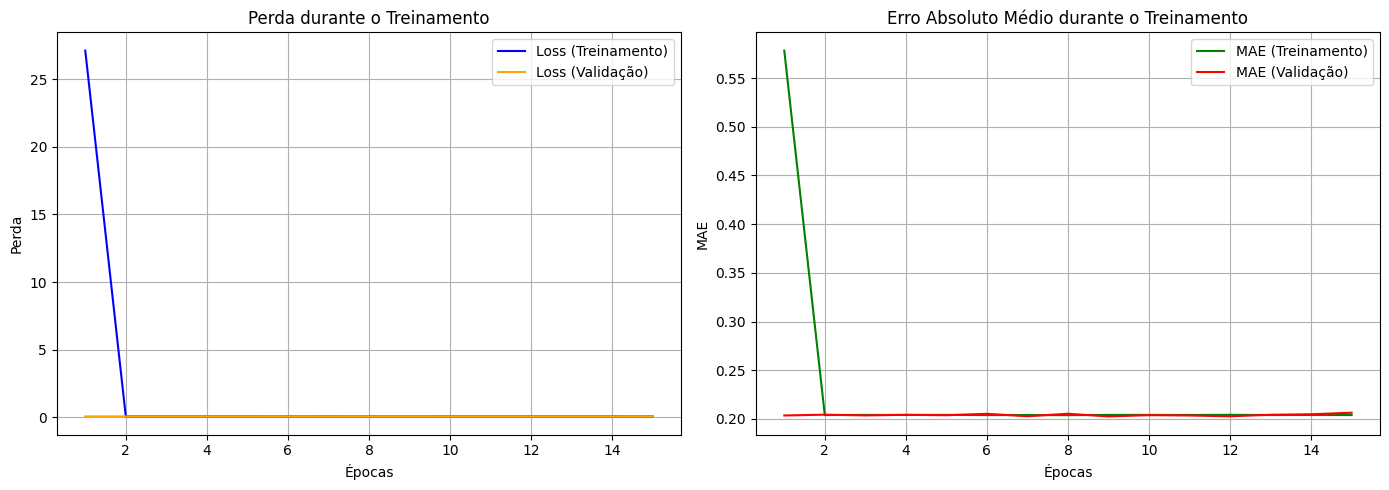

In [153]:
import matplotlib.pyplot as plt

# Obter os dados de histórico do treinamento
loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']

# Número de épocas
epochs_range = range(1, epochs + 1)

# Plotar a perda
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Loss (Treinamento)', color='blue')
plt.plot(epochs_range, val_loss, label='Loss (Validação)', color='orange')
plt.title('Perda durante o Treinamento')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid()

# Plotar o MAE
plt.subplot(1, 2, 2)
plt.plot(epochs_range, mae, label='MAE (Treinamento)', color='green')
plt.plot(epochs_range, val_mae, label='MAE (Validação)', color='red')
plt.title('Erro Absoluto Médio durante o Treinamento')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


In [149]:
import numpy as np
import matplotlib.pyplot as plt

# Prever todas as saídas para X_test
saidas_previstas = model_mlp.predict(X_test)

# Calcular previsões e reais
previsoes = (saidas_previstas * yglobalfoda) / 3600
reais = (y_test * yglobalfoda) / 3600

# Calcular as diferenças
diferencas = reais - previsoes

# Calcular a diferença absoluta
diferencas_absolutas = np.abs(diferencas)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
